
pid_confusion_selected: 268360 matched particles


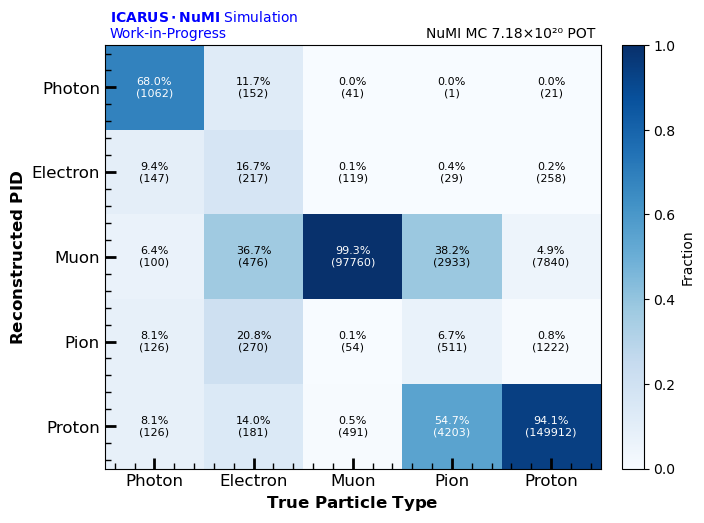

Saved: pid_confusion_selected

pid_confusion_signal: 331014 matched particles


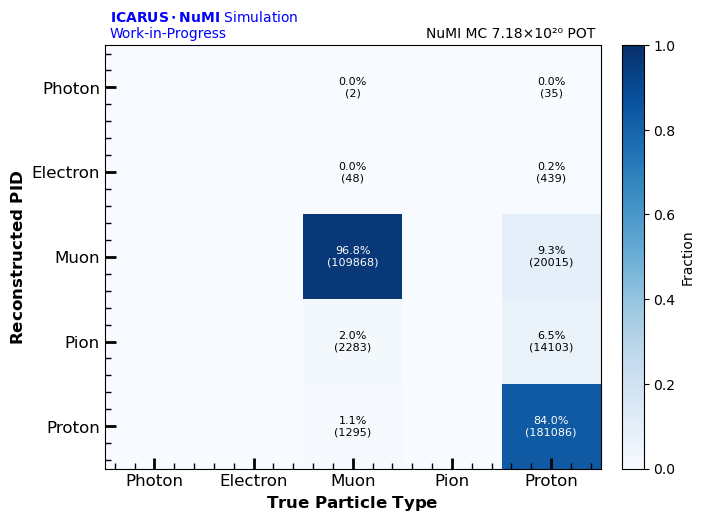

Saved: pid_confusion_signal

pid_confusion_sideband: 156470 matched particles


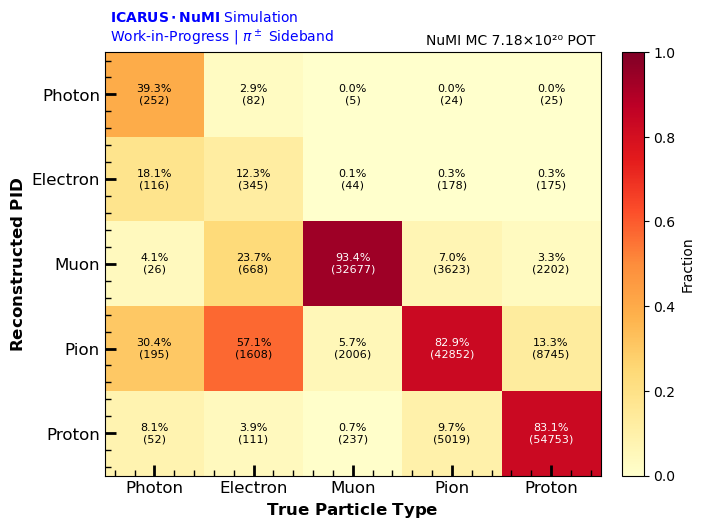

Saved: pid_confusion_sideband

Done.


In [57]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Configuration
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_pid_confusion.root"

OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/PID_SPINE"

PID_LABELS = ["Photon", "Electron", "Muon", "Pion", "Proton"]
N = 5

PDG_TO_COL = {22: 0, 11: 1, 13: 2, 211: 3, 2212: 4}

# tree_name, subtitle, output_name, cmap, white_threshold
TREES = [
    ("pid_confusion_selected", "Work-in-Progress",                       "selected", "Blues",  0.5),
    ("pid_confusion_signal",   "Work-in-Progress",                       "signal",   "Blues",  0.5),
    ("pid_confusion_sideband", r"Work-in-Progress | $\pi^\pm$ Sideband", "sideband", "YlOrRd", 0.6),
]

# ============================================================
# Style helpers
# ============================================================
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=12, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.01 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\n' + subtitle,
            fontsize=10, color="blue",
            verticalalignment="bottom", fontfamily="sans-serif")

# ============================================================
# Build confusion matrix
# ============================================================
def build_confusion(df):
    df_clean = df[df["true_particle_pdg_code"].notna() & df["reco_particle_pid"].notna()].copy()
    counts = np.zeros((N, N), dtype=float)
    for _, row in df_clean.iterrows():
        abs_pdg  = abs(int(row["true_particle_pdg_code"]))
        reco_pid = int(row["reco_particle_pid"])
        if abs_pdg in PDG_TO_COL and 0 <= reco_pid < N:
            true_idx = PDG_TO_COL[abs_pdg]
            counts[reco_pid, true_idx] += 1
    matrix = np.zeros_like(counts)
    for j in range(N):
        col_sum = counts[:, j].sum()
        if col_sum > 0:
            matrix[:, j] = counts[:, j] / col_sum
    return matrix, counts

# ============================================================
# Plot function
# ============================================================
def plot_confusion(matrix, counts, subtitle, output_name, cmap, white_threshold):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=1, aspect='auto')

    for i in range(N):
        for j in range(N):
            val = matrix[i, j]
            cnt = int(counts[i, j])
            if cnt == 0:
                continue
            color = "white" if val > white_threshold else "black"
            ax.text(j, i, f"{val*100:.1f}%\n({cnt})",
                    ha="center", va="center", fontsize=8,
                    color=color, fontfamily="sans-serif")

    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels(PID_LABELS, fontsize=12, fontfamily="sans-serif")
    ax.set_yticklabels(PID_LABELS, fontsize=12, fontfamily="sans-serif")
    ax.set_xlabel(r"$\mathbf{True\ Particle\ Type}$", fontsize=12)
    ax.set_ylabel(r"$\mathbf{Reconstructed\ PID}$", fontsize=12)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Fraction", fontsize=10, fontfamily="sans-serif")

    ax.text(0.99, 1.01, "NuMI MC 7.18×10²⁰ POT",
            transform=ax.transAxes, fontsize=10,
            ha="right", va="bottom", fontfamily="sans-serif")

    add_icarus_label(ax, subtitle=subtitle)
    apply_tick_style(ax)
    ax.grid(False)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/pid_confusion_{output_name}.pdf"),   bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/pid_confusion_{output_name}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved: pid_confusion_{output_name}")

# ============================================================
# Main
# ============================================================
f = uproot.open(DATA_FILE)

for tree_name, subtitle, output_name, cmap, white_threshold in TREES:
    try:
        tree = f[f"events/nominal/{tree_name}"]
        df   = tree.arrays(library="pd")
        df   = df[df["true_particle_pdg_code"].notna()].copy()
        print(f"\n{tree_name}: {len(df)} matched particles")
        matrix, counts = build_confusion(df)
        plot_confusion(matrix, counts, subtitle, output_name, cmap, white_threshold)
    except Exception as e:
        print(f"Skipping {tree_name}: {e}")

print("\nDone.")